# Vision Transformers

Originally, transformers were designed for natural language processing (NLP) tasks, but the Vision Transformer adapts the transformer architecture for image-based tasks. It has shown impressive performance, often surpassing traditional convolutional neural networks (CNNs) in some cases, especially when trained on large datasets.

## Key Concepts of Vision Transformer:
1. **Patch-based Input:**
   - Instead of processing the entire image as a whole, the image is split into fixed-size non-overlapping patches (e.g., 16x16 or 32x32 pixels).
   - These patches are flattened into one-dimensional vectors, essentially transforming the image into a sequence of patches, which is similar to how words are treated in NLP transformers.
2. **Linear Embedding:**
   - Each patch is then flattened into a 1D vector and passed through a linear projection (i.e., a fully connected layer) to create a "patch embedding" of a specific size.
3. **Positional Encoding:**
   - Since transformers do not have any inherent understanding of the spatial relationships between the patches (unlike CNNs), positional encodings are added to the patch embeddings. These encodings provide information about the relative position of each patch in the image.
4. **Transformer Encoder:**
   - The sequence of patch embeddings, with positional encodings, is passed through the transformer’s layers. Each transformer layer consists of a self-attention mechanism and feedforward networks.
   - The self-attention mechanism allows the model to learn relationships and dependencies between different patches of the image, regardless of their distance from each other.
5. **Classification Head:**
   - After passing through the transformer layers, the output corresponding to a special token (often referred to as a classification token or [CLS] token) is used for classification tasks.
   - This final representation is then passed through a feed-forward neural network (a simple classifier) to make predictions (e.g., classify the image into categories).

The transformer encoder layer is the core component of a Vision Transformer. Let's discuss it a bit more. 

### Multi-Head Self-Attention Mechanism:
**1. Query (Q), Key (K), and Value (V) Vectors:**
### 1. Linear Transformations
Each input vector (patch embedding) is linearly transformed into three vectors:

- **Query \(Q\)**: Represents the current patch.
- **Key \(K\)**: Represents other patches' features.
- **Value \(V\)**: Contains the actual information of patches.

For example:

- Input vector for a patch: $x_1 \in \mathbb{R}^{64}$
- Query, Key, Value:
  $$ Q = x_1 W_Q, \, K = x_1 W_K, \, V = x_1 W_V $$
  Here, $W_Q, W_K, W_V \in \mathbb{R}^{64 \times 64}$ are learnable matrices.

**2. Attention Scores:**
The self-attention mechanism computes the similarity between the query of one patch and the keys of all patches (including itself). This is done by computing the dot product between the query vector of each patch and the key vectors of every other patch.

$$\begin{aligned}
\text{Score} = Q \cdot K^T
\end{aligned}$$
- **Scaling**: Scale the scores by $\sqrt{D}$ (to stabilize gradients):
  $$\text{Scaled Score} = \frac{Q \cdot K^T}{\sqrt{D}}$$

- **Softmax**: Apply softmax to get attention weights.

**3. Weighted Sum**
Multiply the attention weights with the value vectors $V$:

$$\text{Attention Output} = \text{Softmax}\left(\frac{Q \cdot K^T}{\sqrt{D}}\right)V$$

**4. Multiple Heads**
Repeat the above process for multiple attention heads, each with different $W_Q, W_K, W_V$. This allows the model to focus on different relationships in parallel.

**5. Concatenate and Project**
- Concatenate outputs from all heads and pass through a final linear layer:
  $$  \text{Output} = \text{Concat}(\text{Head}_1, \text{Head}_2, \dots, \text{Head}_h) W_O$$
  Here, $W_O \in \mathbb{R}^{(h \cdot D) \times D}$ is another learnable matrix.

For better understanding, a example is shown below:

Assumptions for MHSA:
- Number of attention heads $h$ = 4.
- Embedding dimension $D = 128$.
- Dimension per head $(d_{\text{head}}) = \frac{D}{h} = \frac{128}{4} = 32$.


**Linear Transformations (Query, Key, Value)**
Each patch embedding $(128$-dimensional) is transformed into three vectors: Query (Q), Key (K), and Value (V) for each head.

- **Projection Matrices:**
  - $W_Q, W_K, W_V \in \mathbb{R}^{128 \times 128}$.
  - Each projection splits into 4 heads: \(32\)-dimensional vectors per head.

- **Resulting Shapes:**
  - $Q, K, V \in \mathbb{R}^{1024 \times 128}$ (before splitting into heads).
  - Split across 4 heads → $Q, K, V \in \mathbb{R}^{4 \times 1024 \times 32}$.

**Attention Scores (Per Head)**
For each head, compute the scaled dot-product attention:

1. **Score Calculation:**
   - Attention scores are computed as:
     $$\text{Score} = Q \cdot K^T$$
   - For each head:
     - $Q \in \mathbb{R}^{1024 \times 32}$
     - $K^T \in \mathbb{R}^{32 \times 1024}$
     - Result: $\text{Score} \in \mathbb{R}^{1024 \times 1024}$.

2. **Scale Scores:**
   - Scale the scores by \(\sqrt{d_{\text{head}}}\) to stabilize gradients:
     $$\text{Scaled Score} = \frac{\text{Score}}{\sqrt{32}}$$

3. **Softmax:**
   - Apply softmax along the last dimension to get attention weights:
     $$\text{Attention Weights} \in \mathbb{R}^{1024 \times 1024}$$

**Weighted Sum**
- Multiply the attention weights with the Value matrix:
  $$  \text{Attention Output} = \text{Attention Weights} \cdot V $$
- For each head:
  - $\text{Attention Weights} \in \mathbb{R}^{1024 \times 1024}$
  - $V \in \mathbb{R}^{1024 \times 32}$
  - Result: $\text{Attention Output} \in \mathbb{R}^{1024 \times 32}$.

**Concatenate Heads**
- Concatenate the outputs from all 4 heads:
  $$\text{Concat Output} \in \mathbb{R}^{1024 \times (4 \cdot 32)} = \mathbb{R}^{1024 \times 128}$$

**Final Linear Projection**
- Pass the concatenated output through a final linear layer:
  - $W_O \in \mathbb{R}^{128 \times 128}$.
  - Resulting shape: $\mathbb{R}^{1024 \times 128}$.

**Final Dimensions After MHSA:**

| **Step**                 | **Description**              | **Shape**               |
|--------------------------|------------------------------|-------------------------|
| Input to MHSA            | Embedding + Positional Enc. | $1024 \times 128$     |
| Query/Key/Value (split)  | For 4 heads                 | $4 \times 1024 \times 32$ |
| Attention scores         | Dot-product $Q \cdot K^T$ | $4 \times 1024 \times 1024$ |
| Weighted sum (per head)  | $V$ weighted by attention | $4 \times 1024 \times 32$ |
| Concatenate heads        | Combine all heads           | $1024 \times 128$    |
| Final linear projection  | Project back to $128$-dim | $1024 \times 128$     |


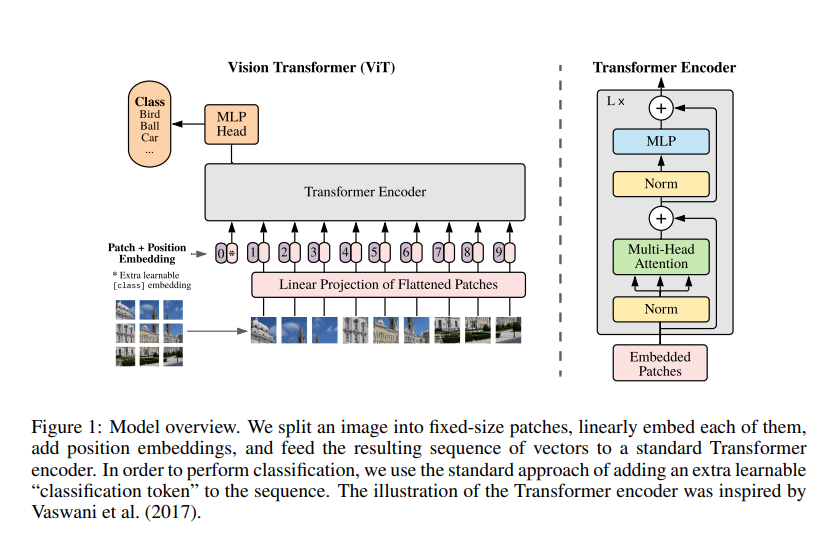

In [1]:
from IPython import display
display.Image("./imgs/ViT.png")

In [2]:
import torch.nn.functional as F
from torch import nn
import torch
import math
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision
import math
import torch.optim as optim
from tqdm.notebook import tqdm
from torch.utils.data import sampler
import torchvision.transforms as T
import torchvision.datasets as datasets

In [3]:
device = 'cuda'

In [4]:
class MSA(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads):
        '''
        input_dim: Dimension of input token embeddings
        embed_dim: Dimension of internal key, query, and value embeddings
        num_heads: Number of self-attention heads
        '''
        super().__init__()

        self.input_dim = input_dim
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        self.K_embed = nn.Linear(input_dim, embed_dim, bias=False)
        self.Q_embed = nn.Linear(input_dim, embed_dim, bias=False)
        self.V_embed = nn.Linear(input_dim, embed_dim, bias=False)
        self.out_embed = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x):
        '''
        x: input of shape (batch_size, max_length, input_dim)
        return: output of shape (batch_size, max_length, embed_dim)
        '''
        batch_size, max_length, given_input_dim = x.shape
        assert given_input_dim == self.input_dim
        assert max_length % self.num_heads == 0
        
        # this implementation projects KQV before splitting into multiple heads
        # but you can also split into multiple heads first
        x = x.reshape(batch_size * max_length, -1)    # (64 * 66, 384)
        K = self.K_embed(x).reshape(batch_size, max_length, self.embed_dim)    # (64, 66, 384)
        Q = self.Q_embed(x).reshape(batch_size, max_length, self.embed_dim)
        V = self.V_embed(x).reshape(batch_size, max_length, self.embed_dim)

        # split each KQV into heads, by reshaping each into (batch_size, max_length, self.num_heads, indiv_dim)
        indiv_dim = self.embed_dim // self.num_heads
        K = K.reshape(batch_size, max_length, self.num_heads, indiv_dim)    # (64, 66, 6, 64)
        Q = Q.reshape(batch_size, max_length, self.num_heads, indiv_dim)
        V = V.reshape(batch_size, max_length, self.num_heads, indiv_dim)

        K = K.permute(0, 2, 1, 3) # (batch_size, num_heads, max_length, embed_dim / num_heads) = (64, 6, 66, 64)
        Q = Q.permute(0, 2, 1, 3)
        V = V.permute(0, 2, 1, 3)

        K = K.reshape(batch_size * self.num_heads, max_length, indiv_dim)    # (64*6, 66, 64)
        Q = Q.reshape(batch_size * self.num_heads, max_length, indiv_dim)
        V = V.reshape(batch_size * self.num_heads, max_length, indiv_dim)

        K_T = K.permute(0, 2, 1) # This is our K transposed so we can do a simple batched matrix multiplication (see torch.bmm for more details and the quick solution)
        QK = torch.bmm(Q, K_T) # compute the weights before dividing by square root of d (batch_size * num_heads, max_length, max_length)
        
        # calculate weights by dividing everything by the square root of d (self.embed_dim)
        weights = QK / math.sqrt(self.embed_dim)
        weights = F.softmax(weights, dim=-1) # Take the softmax over the last dimension (batch_size * num_heads, max_length, max_length)
    
        # get weighted average torch.bmm
        w_V = torch.bmm(weights, V) # weights is (batch_size * num_heads, max_length, max_length) and V is (batch_size * self.num_heads, max_length, indiv_dim), so we want the matrix multiple of weights @ V
    
        # rejoin heads
        w_V = w_V.reshape(batch_size, self.num_heads, max_length, indiv_dim)
        w_V = w_V.permute(0, 2, 1, 3) # (batch_size, max_length, num_heads, embed_dim / num_heads)
        w_V = w_V.reshape(batch_size, max_length, self.embed_dim)
    
        out = self.out_embed(w_V)    # (64, 66, 384)
        return out

In [5]:
class ViTLayer(nn.Module):
  def __init__(self, num_heads, input_dim, embed_dim, mlp_hidden_dim, dropout=0.1):
    '''
    num_heads: Number of heads for multi-head self-attention
    embed_dim: Dimension of internal key, query, and value embeddings
    mlp_hidden_dim: Hidden dimension of the linear layer
    dropout: Dropout rate
    '''

    super().__init__()

    self.input_dim = input_dim
    self.msa = MSA(input_dim, embed_dim, num_heads)

    self.layernorm1 = nn.LayerNorm(embed_dim)
    self.w_o_dropout = nn.Dropout(dropout)
    self.layernorm2 = nn.LayerNorm(embed_dim)
    self.mlp = nn.Sequential(nn.Linear(embed_dim, mlp_hidden_dim),
                              nn.GELU(),
                              nn.Dropout(dropout),
                              nn.Linear(mlp_hidden_dim, embed_dim),
                              nn.Dropout(dropout))

  def forward(self, x):
    '''
    x: input embeddings (batch_size, max_length, input_dim)
    return: output embeddings (batch_size, max_length, embed_dim)
    '''
    residual = x
    # 1) LayerNorm of x
    out = self.layernorm1(x)
    # 2) Self-Attention on output of 1)
    out = self.msa(out)
    # 3) Dropout
    out = self.w_o_dropout(out)
    # 4) Residual w/ original x
    out += residual
    residual = out
    # 5) LayerNorm
    out = self.layernorm2(out)
    # 6) MLP
    out = self.mlp(out)
    # 7) Residual
    return out+residual


In [6]:
class ViT(nn.Module):
  def __init__(self, patch_dim, image_dim, num_layers, num_heads, embed_dim, mlp_hidden_dim, num_classes, dropout):
    '''
    patch_dim: patch length and width to split image by
    image_dim: image length and width
    num_layers: number of layers in network
    num_heads: number of heads for multi-head attention
    embed_dim: dimension to project images patches to and dimension to use for position embeddings
    mlp_hidden_dim: hidden dimension of linear layer
    num_classes: number of classes to classify in data
    dropout: dropout rate
    '''

    super().__init__()
    self.num_layers = num_layers    # 12
    self.patch_dim = patch_dim      # 4
    self.image_dim = image_dim      # 32
    self.input_dim = self.patch_dim * self.patch_dim * 3    # 4x4x3  = 48
    self.num_heads = num_heads      # 6

    self.patch_embedding = nn.Linear(self.input_dim, embed_dim)    # (48 --> 384)
    self.position_embedding = nn.Parameter(torch.zeros(1, (image_dim // patch_dim) ** 2 + 1, embed_dim))    # (1, 65, 384)
    self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))    # 1x1x384
    self.embedding_dropout = nn.Dropout(dropout)

    self.encoder_layers = nn.ModuleList([])
    for i in range(num_layers):
      self.encoder_layers.append(ViTLayer(num_heads, embed_dim, embed_dim, mlp_hidden_dim, dropout))

    self.mlp_head = nn.Linear(embed_dim, num_classes)    # 384 to 10
    self.layernorm = nn.LayerNorm(embed_dim)

  def forward(self, images):
    '''
    images: raw image data (batch_size, channels, rows, cols)
    '''
    # Put the preprocessed patches in variable "out" with shape (batch_size, length, embed_dim).

    # You can make image patches with .reshape
    # x = torch.ones((100, 100))
    # x_patches = x.reshape(4, 25, 4, 25)
    # where you have 4 * 4 patches with each patch being 25 by 25

    h = w = self.image_dim // self.patch_dim    # 32 // 4 = 8
    N = images.size(0)                          # batch_size = 64
    images = images.reshape(N, 3, h, self.patch_dim, w, self.patch_dim)   # (64, 3, 8, 4, 8 ,4)
    images = torch.einsum("nchpwq -> nhwpqc", images)                     # (64, 3, 8, 4, 8 ,4) --> (64, 8, 8, 4, 4, 3)
    patches = images.reshape(N, h * w, self.input_dim) # (batch, num_patches_per_image, patch_size_unrolled) (64, 64, 48)
    # The patches are encoded into embeddings of dimeniosn 384
    patch_embeddings = self.patch_embedding(patches) # Pass through our patch embedding layer (64, 64, 384)
    # concatenate the cls tokens to the embeddings
    patch_embeddings = torch.cat([torch.tile(self.cls_token, (N, 1, 1)), patch_embeddings], dim=1)    # (B, 65, 384)
    out = patch_embeddings + torch.tile(self.position_embedding, (N, 1, 1)) # We add positional embeddings to our tokens (not concatenated)
    out = self.embedding_dropout(out) # Pass through our embedding dropout layer

    # add padding s.t. input length is multiple of num_heads
    add_len = (self.num_heads - out.shape[1]) % self.num_heads    # (6-65)%6
    out = torch.cat([out, torch.zeros(N, add_len, out.shape[2], device=device)], dim=1)    # (B, 66, 384)

    # Pass through each one of our encoder layers
    for encoder_layer in self.encoder_layers:
        out = encoder_layer(out)

    # Pop off and read our classification token we added, see what the value is
    cls_head = self.layernorm(torch.squeeze(out[:, 0], dim=1))    # (64, 384)
    logits = self.mlp_head(cls_head)    # (64, 10)
    return logits

def get_vit_tiny(num_classes=10, patch_dim=4, image_dim=32):
    return ViT(patch_dim=patch_dim, image_dim=image_dim, num_layers=12, num_heads=3,
              embed_dim=192, mlp_hidden_dim=768, num_classes=num_classes, dropout=0.1)

def get_vit_small(num_classes=10, patch_dim=4, image_dim=32):
    return ViT(patch_dim=patch_dim, image_dim=image_dim, num_layers=12, num_heads=6,
               embed_dim=384, mlp_hidden_dim=1536, num_classes=num_classes, dropout=0.1)

## Dataset Loading:

In [7]:
data_root = './data/cifar10'
train_size = 40000
val_size = 10000

batch_size = 64

transform_train = T.Compose([
    T.Resize(40),
    T.RandomCrop(32),
    T.RandomHorizontalFlip(),
    T.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.95, 1.05)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

transform_val = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transform_train,
)

val_dataset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transform_val,
)



train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          sampler=sampler.SubsetRandomSampler(range(train_size)))

val_loader = DataLoader(val_dataset, batch_size=batch_size,
                        sampler=sampler.SubsetRandomSampler(range(train_size, 50000)))


classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


In [8]:
print(f"Length of training DataLoader: {len(train_loader)}")
print(f"Length of validation DataLoader: {len(val_loader)}")

Length of training DataLoader: 625
Length of validation DataLoader: 157


## Training Loop
The goal is get test accuracy greater than 60% after 30 epoches. 

In [9]:
# Get the model and load to it to GPU
vit = get_vit_small().to(device)
vit = torch.nn.DataParallel(vit)

#Hyper-parameters
learning_rate = 5e-4 * batch_size / 256
num_epochs = 30
weight_decay = 0.1

# Loss function and optimiser
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vit.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=weight_decay)

train_losses = []
val_losses = []
val_accuracies = []
for epoch in range(num_epochs):
    train_loss = 0.0
    train_acc = 0.0
    train_total = 0
    vit.train()
    for inputs, labels in tqdm(train_loader):
        """
        1. Set inputs and labels to be on device
        2. zero out our gradients
        3. pass our inputs through the ViT
        4. pass our outputs / labels into our loss / criterion
        5. backpropagate
        6. step our optimizeer
        """
        inputs = inputs.to(device)    # (64, 3, 32, 32)
        labels = labels.to(device)    # (64)

        optimizer.zero_grad()
        outputs = vit(inputs)
        
        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()
        
        train_loss += loss.item() * inputs.shape[0]
        train_acc += torch.sum((torch.argmax(outputs, dim=1) == labels)).item()
        train_total += inputs.shape[0]
    train_loss = train_loss / train_total
    train_acc = train_acc / train_total
    train_losses.append(train_loss)

    val_loss = 0.0
    val_acc = 0.0
    val_total = 0
    vit.eval()
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)    # (64, 3, 32, 32)
            labels = labels.to(device)    # (64)

            outputs = vit(inputs)
            loss = criterion(outputs, labels.long())

            val_loss += loss.item() * inputs.shape[0]
            val_acc += torch.sum((torch.argmax(outputs, dim=1) == labels)).item()
            val_total += inputs.shape[0]
    val_loss = val_loss / val_total
    val_acc = val_acc / val_total
    val_losses.append(val_loss)

    val_accuracies.append(val_acc)
    if val_acc >= max(val_accuracies):
        torch.save(vit.state_dict(), 'best_model.pth')

    print(f'[{epoch + 1:2d}] train loss: {train_loss:.3f} | train accuracy: {train_acc:.3f} | val_loss: {val_loss:.3f} | val_accuracy: {val_acc:.3f}')

print('Finished Training')

  0%|          | 0/625 [00:00<?, ?it/s]

[ 1] train loss: 1.898 | train accuracy: 0.276 | val_loss: 1.766 | val_accuracy: 0.340


  0%|          | 0/625 [00:00<?, ?it/s]

[ 2] train loss: 1.687 | train accuracy: 0.372 | val_loss: 1.623 | val_accuracy: 0.407


  0%|          | 0/625 [00:00<?, ?it/s]

...

[28] train loss: 0.797 | train accuracy: 0.716 | val_loss: 1.098 | val_accuracy: 0.645


  0%|          | 0/625 [00:00<?, ?it/s]

[29] train loss: 0.780 | train accuracy: 0.724 | val_loss: 1.183 | val_accuracy: 0.623


  0%|          | 0/625 [00:00<?, ?it/s]

[30] train loss: 0.765 | train accuracy: 0.731 | val_loss: 1.046 | val_accuracy: 0.652
Finished Training


Finally. check the test accuracy to see how our model did after 30 epochs. 

In [11]:
cifar_test = datasets.CIFAR10('./data/cifar10_test', download = True, train = False, transform = transform_val)
loader_test = DataLoader(cifar_test, batch_size=32, shuffle=False)

vit.load_state_dict(torch.load('best_model.pth'))
vit.eval()  # set model to evaluation mode
test_acc = 0.0
test_total = 0.0
with torch.no_grad():
    for x, labels in loader_test:
        x = x.to(device=device)  # move to device, e.g. GPU
        labels = labels.to(device=device)
        outputs = vit(x)
        test_acc += torch.sum((torch.argmax(outputs, dim=1) == labels)).item()
        test_total += x.shape[0]
    test_acc = test_acc / test_total
print(f'Test Accuracy = {test_acc:.3f}')

Files already downloaded and verified


/tmp/ipykernel_75340/2163370190.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vit.load_state_dict(torch.load('best_model.pth'))


Test Accuracy = 0.669
